# Vector Databases with FAISS — A Complete Beginner's Guide

## What is a Vector Database?

A **vector database** stores and retrieves data as **high-dimensional vectors** (arrays of floats).
Unlike traditional databases that filter by exact values (`WHERE name = 'Alice'`), a vector DB
finds items that are *most similar* to a query — measured by the geometric distance between vectors.

## Core Concepts

| Term | What it means |
|------|--------------|
| **Vector / Embedding** | A fixed-length list of floats representing an object (text, image, …) |
| **Dimension (d)** | How many floats are in each vector (e.g. 128, 384, 1536) |
| **k-NN** | k-Nearest Neighbors — the k vectors closest to a query |
| **Index** | A data structure that organises vectors for fast search |
| **ANN** | Approximate Nearest Neighbor — fast but slightly less accurate than exact k-NN |

## What is FAISS?

**FAISS** (Facebook AI Similarity Search) is an open-source library by Meta AI.
It is one of the fastest, most widely-used tools for vector similarity search,
supporting CPU and GPU, exact and approximate algorithms, billions of vectors.

## Roadmap (increasing complexity)
1. Create & understand vectors
2. Exact search — `IndexFlatL2`
3. Visualise search in 2D
4. Distance metrics — L2 vs Cosine
5. Store metadata alongside vectors
6. Approximate search — `IndexIVFFlat` and `IndexHNSWFlat`
7. Save & load an index
8. Real-world semantic text search with Sentence Transformers  

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS — run this cell first every time you open the notebook
# ─────────────────────────────────────────────────────────────────────────────
import faiss                               # Main vector search library (Meta AI)
import numpy as np                         # Array math — all vectors are numpy arrays
import matplotlib.pyplot as plt            # Visualisations
from sklearn.decomposition import PCA      # Dimensionality reduction (used for 2D plots)
from sklearn.preprocessing import normalize  # L2-normalisation helper
import time                                # Benchmarking search speed
import pickle                              # Serialising Python objects (metadata)
import os                                  # File operations

np.random.seed(42)   # Reproducible results throughout this notebook

print("All libraries loaded successfully!")
print(f"  FAISS   version : {faiss.__version__}")
print(f"  NumPy   version : {np.__version__}")

All libraries loaded successfully!
  FAISS   version : 1.13.2
  NumPy   version : 2.2.6


---
## Section 1 — Understanding Vectors

Before touching FAISS, let's understand what a **vector** is.

A vector is a **list of numbers** that encodes the properties of something.

**Example — representing a fruit by 4 properties:**

```
          sweetness  acidity  size  weight
apple  =  [   8.0,     5.0,   7.0,   6.0 ]
lemon  =  [   2.0,     9.0,   4.0,   3.0 ]
orange =  [   7.0,     4.0,   8.0,   7.0 ]
```

- Apple and orange are *similar* → their vectors are **close together** in 4D space.
- Apple and lemon are *different* → their vectors are **far apart**.

The **distance** between two vectors measures dissimilarity.

In real applications, vectors come from **ML models** (called encoders) that transform
text, images, or audio into vectors where *semantic meaning* maps to *geometric proximity*.

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# FAISS always works with:
#   • float32  numpy arrays  (NOT float64)
#   • shape (n_vectors, dimension)  — always 2D, even for a single vector
# ─────────────────────────────────────────────────────────────────────────────

# 4-dimensional fruit vectors: [sweetness, acidity, size, weight]
fruits = {
    "apple":      [8.0, 5.0, 7.0, 6.0],
    "orange":     [7.0, 4.0, 8.0, 7.0],
    "lemon":      [2.0, 9.0, 4.0, 3.0],
    "grapefruit": [4.0, 7.0, 8.0, 8.0],
    "pear":       [7.0, 3.0, 6.0, 5.0],
}

fruit_names = list(fruits.keys())

# Stack into a 2D matrix — shape (5, 4)
# dtype=np.float32 is REQUIRED by FAISS
vectors = np.array(list(fruits.values()), dtype=np.float32)

print(f"Matrix shape: {vectors.shape}  → ({len(fruits)} fruits × 4 dimensions)\n")

for name, vec in zip(fruit_names, vectors):
    print(f"  {name:12s}: {vec}")

# Let's also compute the L2 distance between apple and lemon manually
apple = vectors[0]
lemon = vectors[2]
l2_dist = np.sqrt(np.sum((apple - lemon) ** 2))
print(f"\nManual L2 distance(apple, lemon) = {l2_dist:.4f}")
print("  (FAISS will compute this for all pairs, instantly, even with millions of vectors)")


Matrix shape: (5, 4)  → (5 fruits × 4 dimensions)

  apple       : [8. 5. 7. 6.]
  orange      : [7. 4. 8. 7.]
  lemon       : [2. 9. 4. 3.]
  grapefruit  : [4. 7. 8. 8.]
  pear        : [7. 3. 6. 5.]

Manual L2 distance(apple, lemon) = 8.3666
  (FAISS will compute this for all pairs, instantly, even with millions of vectors)


---
## Section 2 — Your First FAISS Index

### `IndexFlatL2` — Exact Nearest Neighbor Search

`IndexFlatL2` is the simplest FAISS index:
- **Exact** — checks every vector, results are 100% accurate
- **L2 distance** (Euclidean) — straight-line distance between two points
- **No training required** — just create, add, and search

**L2 distance formula:**

$$d(a, b) = \sqrt{\sum_{i=1}^{d} (a_i - b_i)^2}$$

Lower distance = **more similar**. Distance = 0 means **identical vectors**.

**When to use `IndexFlatL2`:**
- Small datasets (up to ~100k vectors)
- When you need 100% accuracy
- As a baseline to verify the accuracy of approximate indexes

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Creating an IndexFlatL2 — three steps: create → add → search
# ─────────────────────────────────────────────────────────────────────────────

DIMENSION = 4   # Must match the dimension of your vectors

# Step 1: Create the index
# Only argument is the vector dimension — nothing else needed for FlatL2
index = faiss.IndexFlatL2(DIMENSION)

print(f"Index type  : {type(index).__name__}")
print(f"Dimension   : {index.d}")
print(f"Vectors     : {index.ntotal}  ← empty so far")

# Step 2: Add vectors to the index
# add() expects shape (n, d) and dtype float32
index.add(vectors)

print(f"\nAfter index.add():")
print(f"Vectors     : {index.ntotal}  ← 5 fruits loaded")

# FAISS assigns sequential integer IDs: 0, 1, 2, ...
# in the ORDER vectors were added. That's your mapping!
print("\nFAISS ID → Fruit:")
for i, name in enumerate(fruit_names):
    print(f"  ID {i} → {name}")


Index type  : IndexFlatL2
Dimension   : 4
Vectors     : 0  ← empty so far

After index.add():
Vectors     : 5  ← 5 fruits loaded

FAISS ID → Fruit:
  ID 0 → apple
  ID 1 → orange
  ID 2 → lemon
  ID 3 → grapefruit
  ID 4 → pear


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Searching: index.search(query_matrix, k)
#
# Returns two arrays:
#   distances  shape (n_queries, k) — L2 distances (lower = more similar)
#   indices    shape (n_queries, k) — FAISS IDs of the k nearest vectors
#
# CRITICAL: query shape must always be (n, d) — 2D, never 1D!
# ─────────────────────────────────────────────────────────────────────────────

k = 3   # How many nearest neighbours to retrieve

# ── Query 1: What is most similar to "apple"? ─────────────────────────────
# vectors[0:1]  → shape (1, 4)  ✓
# vectors[0]    → shape (4,)    ✗  FAISS will raise an error!
query_apple = vectors[0:1]

distances, indices = index.search(query_apple, k)

print("=== Query: What fruits are most similar to 'apple'? ===")
print(f"Query vector: {query_apple[0]}\n")

for rank, (dist, idx) in enumerate(zip(distances[0], indices[0])):
    name = fruit_names[idx]
    note = "  ← apple itself (distance = 0)" if dist == 0 else ""
    print(f"  Rank {rank+1}: {name:12s}  L2 distance = {dist:.4f}{note}")

# ── Query 2: A brand-new "mystery" fruit not in the database ──────────────
print("\n=== Query: Mystery fruit [6.0, 5.0, 7.0, 6.0] ===")
mystery = np.array([[6.0, 5.0, 7.0, 6.0]], dtype=np.float32)
distances, indices = index.search(mystery, k)

for rank, (dist, idx) in enumerate(zip(distances[0], indices[0])):
    print(f"  Rank {rank+1}: {fruit_names[idx]:12s}  L2 distance = {dist:.4f}")

print("\n→ The mystery fruit is closest to apple and pear — makes intuitive sense!")


=== Query: What fruits are most similar to 'apple'? ===
Query vector: [8. 5. 7. 6.]

  Rank 1: apple         L2 distance = 0.0000  ← apple itself (distance = 0)
  Rank 2: orange        L2 distance = 4.0000
  Rank 3: pear          L2 distance = 7.0000

=== Query: Mystery fruit [6.0, 5.0, 7.0, 6.0] ===
  Rank 1: apple         L2 distance = 4.0000
  Rank 2: orange        L2 distance = 4.0000
  Rank 3: pear          L2 distance = 7.0000

→ The mystery fruit is closest to apple and pear — makes intuitive sense!


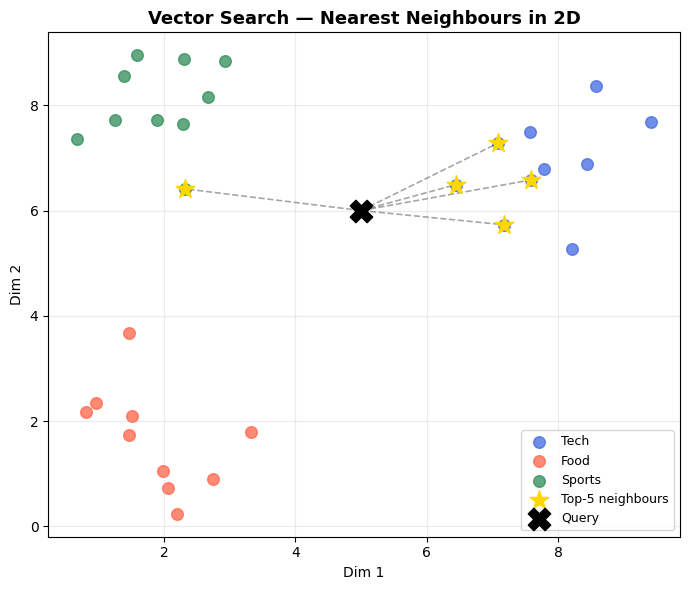


Nearest neighbours to query point (5.0, 6.0):
  1. Point # 7 (Tech  ) — L2 distance = 2.339
  2. Point # 9 (Tech  ) — L2 distance = 4.838
  3. Point # 8 (Tech  ) — L2 distance = 6.007
  4. Point # 5 (Tech  ) — L2 distance = 7.009
  5. Point #24 (Sports) — L2 distance = 7.411


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualising Vector Search in 2D
# ─────────────────────────────────────────────────────────────────────────────
# Real embeddings are hundreds of dimensions, but 2D lets us SEE what
# "nearest neighbour" means geometrically. We create three clusters:
# Tech (top-right), Food (bottom-left), Sports (top-left).
# ─────────────────────────────────────────────────────────────────────────────

np.random.seed(42)

cluster_cfg = {
    "Tech":   {"center": [8, 7], "color": "royalblue"},
    "Food":   {"center": [2, 2], "color": "tomato"},
    "Sports": {"center": [2, 8], "color": "seagreen"},
}

all_pts, labels = [], []
for cat, cfg in cluster_cfg.items():
    pts = np.random.normal(loc=cfg["center"], scale=0.9, size=(10, 2)).astype(np.float32)
    all_pts.append(pts)
    labels.extend([cat] * 10)

all_pts = np.vstack(all_pts)   # shape: (30, 2)

# Build the 2D FAISS index
idx2d = faiss.IndexFlatL2(2)
idx2d.add(all_pts)

# A query point sitting between the clusters
query_2d = np.array([[5.0, 6.0]], dtype=np.float32)
K_VIS = 5
dists_vis, nbrs_vis = idx2d.search(query_2d, K_VIS)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

for cat, cfg in cluster_cfg.items():
    mask = [l == cat for l in labels]
    pts = all_pts[mask]
    ax.scatter(pts[:, 0], pts[:, 1], c=cfg["color"], s=70, label=cat, alpha=0.75)

# Draw dashed lines from query to each neighbour
nn_pts = all_pts[nbrs_vis[0]]
for pt in nn_pts:
    ax.plot([query_2d[0, 0], pt[0]], [query_2d[0, 1], pt[1]],
            "k--", alpha=0.35, lw=1.2)

# Highlight nearest neighbours
ax.scatter(nn_pts[:, 0], nn_pts[:, 1], c="gold", s=200, marker="*",
           zorder=5, label=f"Top-{K_VIS} neighbours")

# Query point
ax.scatter(*query_2d[0], c="black", s=260, marker="X", zorder=6, label="Query")

ax.set_title("Vector Search — Nearest Neighbours in 2D", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print("\nNearest neighbours to query point (5.0, 6.0):")
for i, (d, n) in enumerate(zip(dists_vis[0], nbrs_vis[0])):
    print(f"  {i+1}. Point #{n:2d} ({labels[n]:6s}) — L2 distance = {d:.3f}")


---
## Section 3 — Distance Metrics

Different problems call for different similarity measures:

| Metric | FAISS Index | Score meaning | Best for |
|--------|-------------|---------------|----------|
| **L2 (Euclidean)** | `IndexFlatL2` | lower = closer | Numeric vectors, images |
| **Inner Product** | `IndexFlatIP` | higher = closer | Dot-product models |
| **Cosine Similarity** | `IndexFlatIP` + normalise vectors first | higher = closer | Text, NLP embeddings |

### L2 vs Cosine — the key difference

- **L2** cares about both the **direction** and the **magnitude** (length) of the vector.
- **Cosine** cares only about the **direction** — two vectors pointing the same way score 1.0
  regardless of how long they are.

For **text embeddings** cosine similarity is almost always the right choice, because the
*direction* of the embedding encodes meaning, not its length.

### How to get cosine similarity in FAISS

1. L2-normalise every vector before inserting: `v = v / ‖v‖`
2. Use `IndexFlatIP`
3. Now Inner Product = Cosine Similarity (because both norms = 1)

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Comparing L2 distance vs Cosine similarity on the same set of vectors
# ─────────────────────────────────────────────────────────────────────────────

DIM_METRIC = 8
np.random.seed(0)
raw = np.random.randn(6, DIM_METRIC).astype(np.float32)

# L2-normalise: divide each row by its own Euclidean norm
# After this every vector has magnitude 1.0, so dot(a, b) == cosine(a, b)
norms = np.linalg.norm(raw, axis=1, keepdims=True)
normed = (raw / norms).astype(np.float32)

# ── L2 Search ────────────────────────────────────────────────────────────
idx_l2 = faiss.IndexFlatL2(DIM_METRIC)
idx_l2.add(raw)
D_l2, I_l2 = idx_l2.search(raw[0:1], k=4)

print("=== L2 distance (lower = more similar) ===")
for rank, (d, i) in enumerate(zip(D_l2[0], I_l2[0])):
    print(f"  Rank {rank+1}: vector #{i}  score = {d:.4f}")

# ── Cosine Similarity Search ──────────────────────────────────────────────
idx_ip = faiss.IndexFlatIP(DIM_METRIC)
idx_ip.add(normed)
D_ip, I_ip = idx_ip.search(normed[0:1], k=4)

print("\n=== Cosine similarity via IndexFlatIP + normalised vectors (higher = more similar) ===")
for rank, (d, i) in enumerate(zip(D_ip[0], I_ip[0])):
    print(f"  Rank {rank+1}: vector #{i}  cosine = {d:.4f}")

# ── Verify the maths ─────────────────────────────────────────────────────
print("\n=== Verification: manual cosine == IndexFlatIP score ===")
for i in range(6):
    manual = float(np.dot(normed[0], normed[i]))
    print(f"  v0 · v{i} (manual) = {manual:.4f}")

print("\nRule: normalise first, then use IndexFlatIP to get cosine similarity.")


=== L2 distance (lower = more similar) ===
  Rank 1: vector #0  score = 0.0000
  Rank 2: vector #1  score = 7.7259
  Rank 3: vector #3  score = 17.4717
  Rank 4: vector #4  score = 25.7750

=== Cosine similarity via IndexFlatIP + normalised vectors (higher = more similar) ===
  Rank 1: vector #0  cosine = 1.0000
  Rank 2: vector #1  cosine = 0.7372
  Rank 3: vector #3  cosine = 0.3449
  Rank 4: vector #5  cosine = -0.1147

=== Verification: manual cosine == IndexFlatIP score ===
  v0 · v0 (manual) = 1.0000
  v0 · v1 (manual) = 0.7372
  v0 · v2 (manual) = -0.2739
  v0 · v3 (manual) = 0.3449
  v0 · v4 (manual) = -0.1427
  v0 · v5 (manual) = -0.1147

Rule: normalise first, then use IndexFlatIP to get cosine similarity.


---
## Section 4 — Pairing Vectors with Metadata

FAISS is a **pure vector search engine** — it only stores raw float arrays.
It has no concept of what those vectors represent (documents, images, users, …).

**The pattern everyone uses:**
Build a thin wrapper that maps FAISS integer IDs to your metadata in a Python dict.

```
FAISS index              Metadata dictionary
─────────────────        ──────────────────────────────────────────────────
ID 0 → [0.1, 0.8, …]    0 → {"title": "Intro to Python",  "category": "tech"}
ID 1 → [0.7, 0.2, …]    1 → {"title": "Pasta Recipes",    "category": "food"}
ID 2 → [0.4, 0.6, …]    2 → {"title": "Basketball Tips",  "category": "sports"}
```

FAISS assigns IDs **in insertion order** (0, 1, 2, …).
Keep that mapping consistent — especially when saving/loading.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# SimpleVectorStore — FAISS search + Python dict metadata
# ─────────────────────────────────────────────────────────────────────────────

class SimpleVectorStore:
    """
    Minimal vector store combining FAISS (similarity search) with
    a plain Python dict (metadata). Handles thousands of vectors easily.
    For millions of vectors, consider a dedicated DB like Qdrant or Weaviate.
    """

    def __init__(self, dimension: int):
        self.dim = dimension
        self.index = faiss.IndexFlatL2(dimension)  # The search engine
        self.meta  = {}        # Maps faiss_id (int) → metadata dict
        self._next_id = 0

    def add(self, vector: np.ndarray, metadata: dict):
        """Insert one vector with its metadata."""
        vec = np.asarray(vector, dtype=np.float32).reshape(1, -1)
        self.index.add(vec)
        self.meta[self._next_id] = metadata
        self._next_id += 1

    def add_batch(self, vectors: np.ndarray, metadata_list: list):
        """Insert many vectors at once — much faster than calling add() in a loop."""
        vecs = np.asarray(vectors, dtype=np.float32)
        assert vecs.shape[0] == len(metadata_list)
        self.index.add(vecs)
        for i, m in enumerate(metadata_list):
            self.meta[self._next_id + i] = m
        self._next_id += len(metadata_list)

    def search(self, query: np.ndarray, k: int = 5) -> list:
        """Return k most similar items. Each result is a dict with 'score' + all metadata."""
        q = np.asarray(query, dtype=np.float32).reshape(1, -1)
        distances, indices = self.index.search(q, k)
        results = []
        for dist, idx in zip(distances[0], indices[0]):
            if idx == -1:   # FAISS returns -1 when fewer than k results exist
                continue
            results.append({"score": float(dist), **self.meta[int(idx)]})
        return results

    def __len__(self):
        return self.index.ntotal


# ─── Populate the store ────────────────────────────────────────────────────
store = SimpleVectorStore(dimension=8)

# Simulate category-based embeddings (dims 0-2 = tech, 3-5 = cooking, 6-7 = sports)
BASE_VECS = {
    "tech":    np.array([0.9, 0.8, 0.7, 0.1, 0.1, 0.1, 0.1, 0.1]),
    "cooking": np.array([0.1, 0.1, 0.1, 0.9, 0.8, 0.7, 0.1, 0.1]),
    "sports":  np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.9, 0.8]),
}

docs = [
    {"title": "Introduction to Python",     "category": "tech"},
    {"title": "Machine Learning Basics",    "category": "tech"},
    {"title": "Deep Learning with PyTorch", "category": "tech"},
    {"title": "Italian Pasta Recipes",      "category": "cooking"},
    {"title": "French Cuisine Guide",       "category": "cooking"},
    {"title": "Vegan Meal Prep",            "category": "cooking"},
    {"title": "Football Training Tips",     "category": "sports"},
    {"title": "Basketball Strategy",        "category": "sports"},
]

np.random.seed(42)
for doc in docs:
    base = BASE_VECS[doc["category"]].copy()
    vec  = (base + np.random.randn(8) * 0.1).astype(np.float32)
    store.add(vec, doc)

print(f"Vector store loaded: {len(store)} documents\n")

# ─── Search ────────────────────────────────────────────────────────────────
# Simulate a "tech" query
tech_query = np.array([0.88, 0.83, 0.72, 0.05, 0.05, 0.05, 0.05, 0.05], dtype=np.float32)

print("=== Querying with a tech-like vector ===")
for r in store.search(tech_query, k=5):
    print(f"  score={r['score']:.4f}  |  {r['title']:<35}  [{r['category']}]")


Vector store loaded: 8 documents

=== Querying with a tech-like vector ===
  score=0.0462  |  Machine Learning Basics              [tech]
  score=0.0784  |  Deep Learning with PyTorch           [tech]
  score=0.1104  |  Introduction to Python               [tech]
  score=2.6366  |  Basketball Strategy                  [sports]
  score=2.7989  |  Vegan Meal Prep                      [cooking]


---
## Section 5 — Approximate Nearest Neighbour (ANN) Search

`IndexFlatL2` scans **every vector** for every query.
With 1 million vectors and dimension 128 → 128M multiplications per query. Too slow.

**ANN indexes** pre-organise vectors so only a small fraction need to be examined:

| Index | Method | Training needed? | Best use case |
|-------|--------|-----------------|---------------|
| `IndexFlatL2` | Exact brute-force | No | < 100k vectors, need 100% accuracy |
| `IndexIVFFlat` | k-means clusters | **Yes** | Large batches, good recall, tunable |
| `IndexHNSWFlat` | Navigable graph | No | Streaming data, no retraining needed |

### `IndexIVFFlat` key parameters
- `nlist` — number of clusters (common rule: `sqrt(N)`)
- `nprobe` — clusters checked per query (more → slower but more accurate)

### `IndexHNSWFlat` key parameters
- `M` — connections per node in the graph (8–64)
- `efConstruction` — build quality (higher → better index, slower to build)
- `efSearch` — search quality at query time (can be tuned without rebuilding)

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# IndexIVFFlat — Inverted File Index
# Workflow: train() → add() → search()
# ─────────────────────────────────────────────────────────────────────────────

DIM_ANN   = 64
N_VECS    = 10_000   # generates in < 1 second
N_QUERIES = 20

np.random.seed(42)

# 5 tight clusters so the IVF structure has something meaningful to learn
centres  = (np.random.randn(5, DIM_ANN) * 10).astype(np.float32)
db_vecs  = np.vstack([
    centres[i % 5] + np.random.randn(DIM_ANN).astype(np.float32)
    for i in range(N_VECS)
])
queries  = np.random.randn(N_QUERIES, DIM_ANN).astype(np.float32)

print(f"Dataset : {N_VECS:,} vectors × {DIM_ANN} dims")

# ── Exact baseline (ground truth) ─────────────────────────────────────────
idx_flat = faiss.IndexFlatL2(DIM_ANN)
idx_flat.add(db_vecs)
t0 = time.perf_counter()
D_exact, I_exact = idx_flat.search(queries, k=10)
t_flat = time.perf_counter() - t0

# ── IVFFlat setup ─────────────────────────────────────────────────────────
nlist     = 100   # ≈ sqrt(10_000) — a common starting point
quantizer = faiss.IndexFlatL2(DIM_ANN)   # How to compare cluster centres
idx_ivf   = faiss.IndexIVFFlat(quantizer, DIM_ANN, nlist)

# TRAINING: learns the cluster centres via k-means
# Must be done BEFORE add() and needs at least nlist*39 vectors
print(f"\nTraining IVF (nlist={nlist}) on {N_VECS:,} vectors…")
idx_ivf.train(db_vecs)
idx_ivf.add(db_vecs)
print("Done!")

# nprobe = how many clusters to examine per query
# More nprobe → higher recall, slower search
idx_ivf.nprobe = 10

t0 = time.perf_counter()
D_ivf, I_ivf = idx_ivf.search(queries, k=10)
t_ivf = time.perf_counter() - t0

# ── Recall@10: what % of the exact top-10 did we find? ─────────────────────
recall_ivf = np.mean([
    len(set(I_exact[i]) & set(I_ivf[i])) / 10
    for i in range(N_QUERIES)
])

print(f"\n{'Method':<18} {'Time (ms)':>12}  {'Recall@10':>12}")
print("-" * 46)
print(f"{'FlatL2 (exact)':<18} {t_flat*1e3:>10.2f}ms  {'100.0%':>12}")
print(f"{'IVFFlat':<18} {t_ivf*1e3:>10.2f}ms  {recall_ivf*100:>11.1f}%  (nprobe={idx_ivf.nprobe})")
print("\n→ Increase nprobe to raise recall at the cost of speed.")


Dataset : 10,000 vectors × 64 dims

Training IVF (nlist=100) on 10,000 vectors…
Done!

Method                Time (ms)     Recall@10
----------------------------------------------
FlatL2 (exact)          10.39ms        100.0%
IVFFlat                  2.02ms         70.0%  (nprobe=10)

→ Increase nprobe to raise recall at the cost of speed.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# IndexHNSWFlat — Hierarchical Navigable Small World graph
# No training required — add() builds the graph on the fly
# ─────────────────────────────────────────────────────────────────────────────

M_HNSW = 32   # Connections per graph node — more = better recall, more RAM

idx_hnsw = faiss.IndexHNSWFlat(DIM_ANN, M_HNSW)
idx_hnsw.hnsw.efConstruction = 64   # Build depth: higher → better graph, slower build

print(f"Building HNSW (M={M_HNSW}, efConstruction={idx_hnsw.hnsw.efConstruction})…")
t_build = time.perf_counter()
idx_hnsw.add(db_vecs)   # This IS the build — no separate train() step
t_build = time.perf_counter() - t_build
print(f"Built in {t_build:.2f}s for {N_VECS:,} vectors")

# efSearch can be tuned at query time without rebuilding the index
idx_hnsw.hnsw.efSearch = 64

t0 = time.perf_counter()
D_hnsw, I_hnsw = idx_hnsw.search(queries, k=10)
t_hnsw = time.perf_counter() - t0

recall_hnsw = np.mean([
    len(set(I_exact[i]) & set(I_hnsw[i])) / 10
    for i in range(N_QUERIES)
])

print(f"\n{'Method':<20} {'Time (ms)':>12}  {'Recall@10':>12}  Notes")
print("-" * 72)
print(f"{'FlatL2 (exact)':<20} {t_flat*1e3:>10.2f}ms  {'100.0%':>12}  Exact baseline")
print(f"{'IVFFlat':<20} {t_ivf*1e3:>10.2f}ms  {recall_ivf*100:>11.1f}%  nprobe=10, needs training")
print(f"{'HNSWFlat':<20} {t_hnsw*1e3:>10.2f}ms  {recall_hnsw*100:>11.1f}%  No training, online inserts")
print(
    "\nPractical guidelines:"
    "\n  Small dataset (< 100k)         -> IndexFlatL2   (exact, zero setup)"
    "\n  Large batch dataset             -> IndexIVFFlat  (tune nlist & nprobe)"
    "\n  Streaming / no-retrain needed   -> IndexHNSWFlat (great out-of-the-box recall)"
    "\n"
)


Building HNSW (M=32, efConstruction=64)…
Built in 0.14s for 10,000 vectors

Method                  Time (ms)     Recall@10  Notes
------------------------------------------------------------------------
FlatL2 (exact)            10.39ms        100.0%  Exact baseline
IVFFlat                    2.02ms         70.0%  nprobe=10, needs training
HNSWFlat                   3.69ms         70.0%  No training, online inserts

Practical guidelines:
  Small dataset (< 100k)         -> IndexFlatL2   (exact, zero setup)
  Large batch dataset             -> IndexIVFFlat  (tune nlist & nprobe)
  Streaming / no-retrain needed   -> IndexHNSWFlat (great out-of-the-box recall)



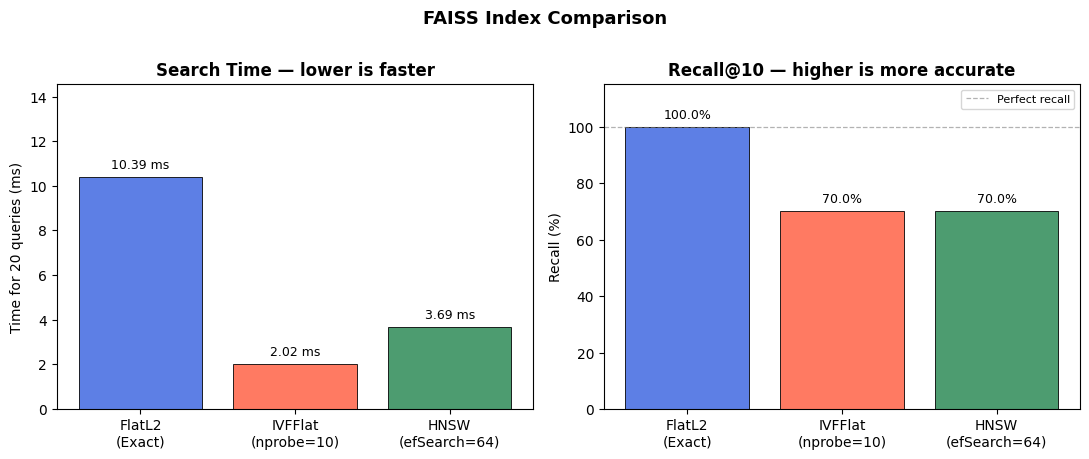

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Visual comparison — Speed vs Recall for the three index types
# ─────────────────────────────────────────────────────────────────────────────

methods   = ["FlatL2\n(Exact)", f"IVFFlat\n(nprobe={idx_ivf.nprobe})", f"HNSW\n(efSearch=64)"]
times_ms  = [t_flat * 1e3, t_ivf * 1e3, t_hnsw * 1e3]
recalls   = [100.0, recall_ivf * 100, recall_hnsw * 100]
bar_clrs  = ["royalblue", "tomato", "seagreen"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# ── Speed ─────────────────────────────────────────────────────────────────
b1 = ax1.bar(methods, times_ms, color=bar_clrs, alpha=0.85, edgecolor="black", lw=0.7)
ax1.bar_label(b1, fmt="%.2f ms", padding=4, fontsize=9)
ax1.set_title("Search Time — lower is faster", fontweight="bold")
ax1.set_ylabel(f"Time for {N_QUERIES} queries (ms)")
ax1.set_ylim(0, max(times_ms) * 1.4)

# ── Recall ────────────────────────────────────────────────────────────────
b2 = ax2.bar(methods, recalls, color=bar_clrs, alpha=0.85, edgecolor="black", lw=0.7)
ax2.bar_label(b2, fmt="%.1f%%", padding=4, fontsize=9)
ax2.set_title("Recall@10 — higher is more accurate", fontweight="bold")
ax2.set_ylabel("Recall (%)")
ax2.set_ylim(0, 115)
ax2.axhline(100, color="grey", ls="--", lw=0.9, alpha=0.6, label="Perfect recall")
ax2.legend(fontsize=8)

plt.suptitle("FAISS Index Comparison", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Persisting an Index + Metadata to Disk
# ─────────────────────────────────────────────────────────────────────────────
# faiss.write_index() / faiss.read_index() handle the FAISS binary.
# pickle handles the metadata dict.
# ALWAYS save and load them together — the index alone is useless without metadata.
# ─────────────────────────────────────────────────────────────────────────────

SAVE_DIR   = "saved_index"
os.makedirs(SAVE_DIR, exist_ok=True)

index_path = os.path.join(SAVE_DIR, "index.faiss")
meta_path  = os.path.join(SAVE_DIR, "metadata.pkl")

# ── Save ─────────────────────────────────────────────────────────────────
faiss.write_index(store.index, index_path)

with open(meta_path, "wb") as f:
    pickle.dump(store.meta, f)

print(f"Saved  FAISS index → {index_path}  ({os.path.getsize(index_path):,} bytes)")
print(f"Saved  metadata    → {meta_path}   ({os.path.getsize(meta_path):,} bytes)")

# ── Load ─────────────────────────────────────────────────────────────────
loaded_index = faiss.read_index(index_path)

with open(meta_path, "rb") as f:
    loaded_meta = pickle.load(f)

print(f"\nLoaded index  : {loaded_index.ntotal} vectors")
print(f"Loaded meta   : {len(loaded_meta)} entries")

# ── Verify it still works ─────────────────────────────────────────────────
print("\nVerification — searching the loaded index with the same tech_query:")
D_loaded, I_loaded = loaded_index.search(tech_query.reshape(1, -1), k=3)

for d, i in zip(D_loaded[0], I_loaded[0]):
    print(f"  {loaded_meta[int(i)]['title']:<35}  score={d:.4f}")

print("\n✓ Index loaded and working correctly.")


Saved  FAISS index → saved_index\index.faiss  (301 bytes)
Saved  metadata    → saved_index\metadata.pkl   (339 bytes)

Loaded index  : 8 vectors
Loaded meta   : 8 entries

Verification — searching the loaded index with the same tech_query:
  Machine Learning Basics              score=0.0462
  Deep Learning with PyTorch           score=0.0784
  Introduction to Python               score=0.1104

✓ Index loaded and working correctly.


---
## Section 7 — Real-World Use Case: Semantic Text Search

All the examples above used hand-crafted or random vectors.
In practice, vectors come from **embedding models** that encode text (or images, audio…)
into vectors where **semantic meaning maps to geometric proximity**.

```
Input text          Embedding model          Output vector
──────────────      ─────────────────        ──────────────────────────────
"machine learning"  →  all-MiniLM-L6-v2  →  [0.02, -0.31, 0.14, …]  384 numbers
"deep learning"     →                    →  [0.01, -0.29, 0.18, …]  ← very close!
"pasta recipe"      →                    →  [-0.4,  0.22, -0.7, …]  ← far away
```

### Why this is powerful

The model captures **meaning**, not keywords.
A query like *"how do computers learn from data?"* will match
*"neural networks are trained on large datasets"* — even though they share no words.

### Model: `all-MiniLM-L6-v2`
| Property | Value |
|----------|-------|
| Size | ~22 MB (cached after first download) |
| Dimension | 384 |
| Speed | Thousands of sentences/second on CPU |
| Task | Semantic sentence similarity |

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Load the embedding model (downloads ~22 MB on first use, then cached)
# ─────────────────────────────────────────────────────────────────────────────

from sentence_transformers import SentenceTransformer

print("Loading 'all-MiniLM-L6-v2' (may download ~22 MB on first run)…")
model = SentenceTransformer("all-MiniLM-L6-v2")
EMB_DIM = model.get_sentence_embedding_dimension()
print(f"Model loaded!  Embedding dimension = {EMB_DIM}\n")

# ── Quick sanity check ────────────────────────────────────────────────────
# Two semantically similar sentences should have high cosine similarity.
# An unrelated sentence should score low.
test_sentences = [
    "I love programming in Python.",          # reference
    "Python is my favourite coding language.", # very similar
    "I enjoy eating pizza.",                   # unrelated
]

embs = model.encode(test_sentences, convert_to_numpy=True)
embs_norm = (embs / np.linalg.norm(embs, axis=1, keepdims=True)).astype(np.float32)

cosines = embs_norm @ embs_norm[0]   # cosine similarity against sentence 0
print("Cosine similarity to 'I love programming in Python.':")
for s, c in zip(test_sentences, cosines):
    bar = "█" * int(c * 20)
    print(f"  {c:.3f} {bar:<20}  \"{s}\"")

print("\n→ Sentences 0 & 1 are semantically close (high score).")
print("   Sentence 2 is about food — correctly scores much lower.")


d:\CodingProjects\SoftUniLLMProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading 'all-MiniLM-L6-v2' (may download ~22 MB on first run)…


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2334.53it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!  Embedding dimension = 384

Cosine similarity to 'I love programming in Python.':
  1.000 ████████████████████  "I love programming in Python."
  0.848 ████████████████      "Python is my favourite coding language."
  0.291 █████                 "I enjoy eating pizza."

→ Sentences 0 & 1 are semantically close (high score).
   Sentence 2 is about food — correctly scores much lower.


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Encode 50 documents across 5 topics, then build a cosine-similarity FAISS index
# Encoding ~50 sentences takes well under 10 seconds on CPU
# ─────────────────────────────────────────────────────────────────────────────

corpus = [
    # ── Technology ──────────────────────────────────────────────────────
    "Python is a popular programming language known for its readability.",
    "Machine learning enables computers to learn from data without explicit rules.",
    "Deep learning uses neural networks with many layers to model complex patterns.",
    "FAISS is a library for efficient vector similarity search developed by Meta AI.",
    "Large language models like GPT are trained on vast amounts of text data.",
    "Docker packages applications with all their dependencies into containers.",
    "Git is a version control system for tracking changes in source code.",
    "REST APIs allow software systems to communicate over HTTP.",
    "SQL is the standard language for querying relational databases.",
    "JavaScript is the primary programming language for web browsers.",
    # ── Science ───────────────────────────────────────────────────────────
    "Photosynthesis converts sunlight into chemical energy stored in glucose.",
    "DNA contains the genetic instructions for all living organisms.",
    "The speed of light in a vacuum is approximately 299,792 km per second.",
    "Quantum mechanics describes the behaviour of matter at the atomic scale.",
    "Climate change refers to long-term shifts in global temperatures.",
    "Black holes are regions where gravity is so strong nothing can escape.",
    "Vaccines train the immune system to fight specific pathogens.",
    "The human genome contains approximately 3 billion DNA base pairs.",
    "Neurons communicate through electrical and chemical signals.",
    "Natural selection is the primary mechanism driving evolution.",
    # ── History ───────────────────────────────────────────────────────────
    "The Roman Empire once spanned Europe, North Africa, and parts of Asia.",
    "The Industrial Revolution began in Britain in the late 18th century.",
    "World War II was the deadliest conflict in history, lasting from 1939 to 1945.",
    "The Renaissance was a cultural revival in Europe between the 14th and 17th centuries.",
    "The Great Wall of China was built over centuries to protect against invasion.",
    "Apollo 11 landed the first humans on the Moon on 20 July 1969.",
    "Gutenberg's printing press revolutionised the spread of knowledge after 1440.",
    "Hieroglyphics were among the earliest writing systems, used in ancient Egypt.",
    "The French Revolution of 1789 fundamentally reshaped European society.",
    "Columbus reached the Americas in 1492, beginning an age of exploration.",
    # ── Sports ────────────────────────────────────────────────────────────
    "Football (soccer) is the world's most popular sport by participation.",
    "The Olympic Games originated in ancient Greece around 776 BC.",
    "LeBron James is regarded as one of the greatest basketball players of all time.",
    "The Tour de France is the most prestigious professional cycling race.",
    "Tennis Grand Slam events: Wimbledon, US Open, French Open, Australian Open.",
    "Swimming provides one of the most complete full-body workouts available.",
    "The FIFA World Cup is held every four years and watched by billions worldwide.",
    "Michael Jordan won 6 NBA championships with the Chicago Bulls.",
    "Usain Bolt holds the 100 m world record at 9.58 seconds.",
    "Rugby union originated in England in the early 19th century.",
    # ── Food & Cooking ────────────────────────────────────────────────────
    "The Mediterranean diet is associated with reduced risk of heart disease.",
    "Fermentation is used to produce bread, beer, wine, cheese, and yogurt.",
    "Sushi is a Japanese dish traditionally prepared with vinegared rice and fish.",
    "The Maillard reaction browns food and creates complex flavours during cooking.",
    "Olive oil is a cornerstone ingredient in Italian and Greek cooking.",
    "Capsaicin in chili peppers activates heat receptors in the mouth.",
    "Coffee is one of the most traded commodities in the world.",
    "French culinary techniques have influenced professional cooking worldwide.",
    "Sourdough bread is leavened naturally by wild yeast and lactic acid bacteria.",
    "Dark chocolate is rich in antioxidants and may have cardiovascular benefits.",
]

print(f"Corpus: {len(corpus)} documents across 5 topics")
print("Encoding with sentence transformer…")

t0 = time.perf_counter()
corpus_embs = model.encode(corpus, show_progress_bar=True, convert_to_numpy=True)
t_enc = time.perf_counter() - t0

print(f"\nEncoded {len(corpus)} docs in {t_enc:.2f}s   shape: {corpus_embs.shape}")

# Normalise for cosine similarity (required when using IndexFlatIP)
corpus_norm = (corpus_embs / np.linalg.norm(corpus_embs, axis=1, keepdims=True)).astype(np.float32)

# Build FAISS index with Inner Product (= cosine similarity after normalisation)
text_index = faiss.IndexFlatIP(EMB_DIM)
text_index.add(corpus_norm)

print(f"Index ready with {text_index.ntotal} vectors  (dim={EMB_DIM})")


Corpus: 50 documents across 5 topics
Encoding with sentence transformer…


Batches: 100%|██████████| 2/2 [00:00<00:00, 12.49it/s]


Encoded 50 docs in 0.17s   shape: (50, 384)
Index ready with 50 vectors  (dim=384)


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Semantic search function + demo queries
# ─────────────────────────────────────────────────────────────────────────────

def semantic_search(query: str, k: int = 5) -> list:
    # Pipeline:
    #  1. Embed the query with the same model used for the corpus
    #  2. Normalise to unit length (must match corpus preprocessing)
    #  3. Search FAISS index — cosine similarity via Inner Product
    #  4. Return list of (similarity_score, document_text) tuples
    q_emb  = model.encode([query], convert_to_numpy=True)
    q_norm = (q_emb / np.linalg.norm(q_emb)).astype(np.float32)
    scores, indices = text_index.search(q_norm, k)
    return [(float(scores[0][i]), corpus[indices[0][i]]) for i in range(k)]


# ── Demo queries — notice these share NO keywords with the matching docs ──
queries = [
    "How do computers learn from data?",          # → ML / deep learning docs
    "What should I eat to stay healthy?",          # → cooking / diet docs
    "Famous athletes and their world records",     # → sports docs
    "Ancient civilisations and early writing",     # → history docs
    "How do plants produce energy from light?",    # → photosynthesis
]

for q in queries:
    print(f"Query : \"{q}\"")
    print("─" * 64)
    for rank, (score, doc) in enumerate(semantic_search(q, k=3), 1):
        bar = "█" * int(score * 30)
        print(f"  {rank}. [{score:.3f}] {bar}")
        print(f"       {doc}")
    print()


Query : "How do computers learn from data?"
────────────────────────────────────────────────────────────────
  1. [0.621] ██████████████████
       Machine learning enables computers to learn from data without explicit rules.
  2. [0.396] ███████████
       Deep learning uses neural networks with many layers to model complex patterns.
  3. [0.395] ███████████
       Large language models like GPT are trained on vast amounts of text data.

Query : "What should I eat to stay healthy?"
────────────────────────────────────────────────────────────────
  1. [0.379] ███████████
       The Mediterranean diet is associated with reduced risk of heart disease.
  2. [0.248] ███████
       Dark chocolate is rich in antioxidants and may have cardiovascular benefits.
  3. [0.202] ██████
       Sushi is a Japanese dish traditionally prepared with vinegared rice and fish.

Query : "Famous athletes and their world records"
────────────────────────────────────────────────────────────────
  1. [0.487] ███

---
## Summary — What You Learned

| Topic | Key Takeaway |
|-------|-------------|
| **Vectors** | Fixed-length float arrays; similarity = geometric closeness |
| **IndexFlatL2** | Exact, no training, scans every vector — great for small datasets |
| **IndexFlatIP** | Use with normalised vectors to get cosine similarity |
| **SimpleVectorStore** | FAISS handles search; a Python dict stores metadata |
| **IndexIVFFlat** | Clusters vectors (requires training); fast approximate search |
| **IndexHNSWFlat** | Graph-based ANN; no training, supports streaming inserts |
| **Persistence** | `faiss.write_index` + `pickle` — always save index + metadata together |
| **Text search** | Encode → normalise → `IndexFlatIP` → cosine similarity |

## What to Explore Next

- **Quantisation** — `IndexIVFPQ` compresses vectors 10–100× to save RAM
- **GPU acceleration** — `faiss.index_cpu_to_gpu()` for massive throughput
- **Metadata filtering** — combine FAISS results with post-hoc Python filtering
- **Managed vector DBs** — Qdrant, Weaviate, Pinecone, Milvus (built on these ideas)
- **RAG pipelines** — use this search engine to feed relevant context to an LLM  